# Legal Clause Classification Engine

This notebook classifies extracted contract clauses into semantic legal categories.

The objective is to transform raw clause names into higher-level legal concepts that can support automated contract review and risk analysis.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/contracts.csv")

df.head()

,contract_type,borrower,lender,amount,clauses,jurisdiction,obligations,file
0,HEALTH FINANCING AGREEMENT,Julia Miller,FINANCIAL BANK OF AMERICA Inc.,"$42,751.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_16.pdf
1,MOTORCYCLE FINANCING AGREEMENT,Patricia Hall,FINANCIAL BANK OF AMERICA Inc.,"$36,160.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_4.pdf
2,HEALTH FINANCING AGREEMENT,Patricia Hall,FINANCIAL BANK OF AMERICA Inc.,"$40,267.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_5.pdf
3,STUDENT LOAN AGREEMENT,Richard Taylor,FINANCIAL BANK OF AMERICA Inc.,"$56,424.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_17.pdf
4,HEALTH FINANCING AGREEMENT,Mary Johnson,FINANCIAL BANK OF AMERICA Inc.,"$48,720.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_7.pdf


In [2]:
import ast

df["clauses"] = df["clauses"].apply(ast.literal_eval)

df["clauses"].head()

0    [PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...
1    [PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...
2    [PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...
3    [PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...
4    [PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...
Name: clauses, dtype: object

In [3]:
clause_categories = {
    "PURPOSE": "General",
    "TERM": "General",
    "PAYMENT": "Financial",
    "GUARANTEES": "Security",
    "INSURANCE": "Compliance",
    "DEFAULT": "Risk",
    "TERMINATION": "Risk",
    "JURISDICTION": "Legal"
}

In [4]:
def classify_clauses(clause_list):

    categories = []

    for clause in clause_list:

        category = clause_categories.get(
            clause,
            "Other"
        )

        categories.append(category)

    return categories

In [5]:
df["clause_categories"] = df["clauses"].apply(
    classify_clauses
)

df[
    [
        "clauses",
        "clause_categories"
    ]
].head()

,clauses,clause_categories
0,"[PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...","[General, General, Financial, Security, Compli..."
1,"[PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...","[General, General, Financial, Security, Compli..."
2,"[PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...","[General, General, Financial, Security, Compli..."
3,"[PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...","[General, General, Financial, Security, Compli..."
4,"[PURPOSE, TERM, PAYMENT, GUARANTEES, INSURANCE...","[General, General, Financial, Security, Compli..."


In [6]:
all_categories = []

for row in df["clause_categories"]:

    all_categories.extend(row)

category_counts = pd.Series(
    all_categories
).value_counts()

category_counts

General       60
Risk          60
Financial     30
Security      30
Compliance    30
Legal         30
Name: count, dtype: int64

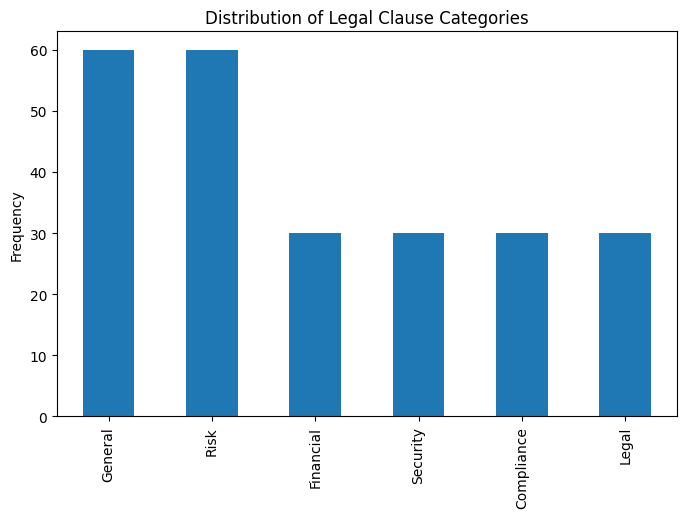

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution of Legal Clause Categories"
)

plt.ylabel("Frequency")

plt.show()